# Figure 5 Non-random formation of multiple touches and morphological variability explain network complexity.

#### A) Connection probabilities along distance considering the existence of previous touches between pairs, computed for the human (top) and the rat (bottom) ATCs. The color gradient represents the number of previous touches from 0 (dark blue) to 10 (dark red). The arrow points to the shift in connection probability along distance at 100 μm for the rat ATC. Analysis of connection probability considering previous touches

In [1]:
import numpy
import pandas

import conntility

from scipy.spatial import distance
from matplotlib import pyplot as plt

#### Load data

Fill in path to ConnectivityMatrix object below.

Also fill in path to output figure and the title to give it.

In [2]:
root_path = "/Users/natali_obi_account/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/"

#Rat
# ATC
fnR = root_path + "Rat_623um_squared_struc_conmat_filtered_compressed.h5"
fnR_out = "touch_count_probs_rat_struct.svg"
figure_title = "Rat: ATC"
#CPC
#fn = root_path + "Rat_623um_squared_funct_conmat_filtered_compressed.h5"
#fn_out = "touch_count_probs_rat_funct.svg"
#figure_title = "Rat: CPC"

#Human
# ATC
#fnH = root_path + "Human_NEWstruct_conmat_filtered_compressed.h5"
#fnH_out = "touch_count_probs_human_struct.svg"
#figure_title_H = "Human: ATC"
#CPC
#fn = root_path + "Human_NEWfunct_conmat_filtered_compressed.h5"
#fn_out = "touch_count_probs_human_funct.svg"
#figure_title = "Human: CPC"

In [3]:
M = conntility.ConnectivityMatrix.from_h5(fnR)
if M.is_multigraph:
    M = M.compress()

## Parameters

In [4]:
max_touch_count = 10 # Plot up to that number of touches
dist_bin_sz = 50 # Size of distance bins in um
min_num_edges_last_bin = 5000 # For distance bins: How many edges must be in the last one at least? Determines distance cutoff
min_num_samples_p = 50 # For the plotting: Probabilities based on fewer than this number of samples are set to NaN (masked out)

cols_xyz = ["x", "y", "z"] # Names of coordinates for distance calculation

## Calculations

In [6]:
# Add distance and distance bin information to the edges.
# The table of edges must contains columns "bin" (distance bin index) and "count" (number of touches). 

sum_deltas = numpy.zeros(len(M.edges))

for axis in cols_xyz:
    prop = M.edge_associated_vertex_properties(axis)
    delta = prop["row"].values - prop["col"].values
    sum_deltas += (delta ** 2)

M.add_edge_property("distance", numpy.sqrt(sum_deltas))

# Linear distance bins (for now)
tgt_percentile = 100 * (1.0 - min_num_edges_last_bin / len(M.edges)) # This way, the last distance bin will contain the specified number of edges.
max_dist = numpy.percentile(M.edges["distance"], tgt_percentile) # There are min_num_edges_last_bin edges beyond that distance!

dbins = numpy.arange(0, max_dist, dist_bin_sz)
dbins[0] = 1E-9
dbin_ids = numpy.arange(len(dbins))
bin_centers = dbins + 0.5 * numpy.mean(numpy.diff(dbins))
M.add_edge_property("bin", numpy.digitize(M.edges["distance"], bins=dbins) - 1)

print(M.edges["bin"].value_counts())

bin
4     10168897
3      9776778
5      9282939
6      7836165
2      7564209
7      6317404
8      4801208
1      3922957
9      3187926
10     1763615
11      914639
0       707487
12      463793
13      228714
14      109742
15       48225
16       18990
17       10330
Name: count, dtype: int64


In [7]:
# for structural and functional
master_table = M.edges.groupby("bin")["count"].value_counts().unstack("count", fill_value=0)

# for pruned matrices
# master_table = M.edges.groupby("bin")["data"].value_counts().unstack("data", fill_value=0)

In [8]:
D = distance.squareform(distance.pdist(M.vertices[cols_xyz]))
D = numpy.digitize(D.flatten(), bins=dbins) - 1
Dcounts = pandas.Series(D, name="bin").value_counts().drop(-1)

master_table[0] = Dcounts - master_table.sum(axis=1) # Zero touches pair count
master_table = master_table.sort_index(axis=1, ascending=False)

In [9]:
P_geq = master_table.cumsum(axis=1) # Number of samples with touch count >= a threshold
P_gt = P_geq.copy() # We shift it by one index -> Number of samples with touch count > a threshold
P_gt.columns = P_gt.columns - 1

condP = P_gt.div(P_geq, fill_value=0).drop(columns=-1)
condP[P_geq < min_num_samples_p] = numpy.nan
condP.columns = condP.columns + 1 # Now index is the touch number: 1 indicating first touch, etc.

## Plotting

Text(0, 0.5, 'Touch #')

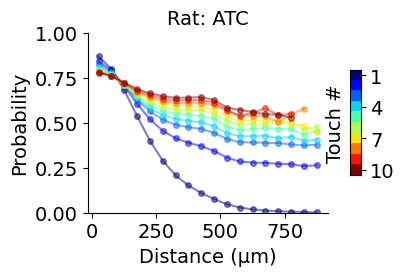

In [11]:
from matplotlib import cm

cmap = cm.jet

#max_touch_count = 7

touches = numpy.arange(1, max_touch_count + 1)
touch_col_v = numpy.linspace(0, 1, len(touches))

fig = plt.figure(figsize=(3, 2))
ax = fig.add_axes([0.05, 0.05, 0.8, 0.9])

for t, v in zip(touches, touch_col_v):
    col = cmap(v)
    ax.plot(bin_centers, condP[t], color=col, alpha=0.5, label="Touch #{0}".format(t), marker='o', ms=4)
    ax.set_ylim(0.0, 1.0)

#ax.set_frame_on(False)
ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel("Distance (µm)", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.set_title(figure_title, fontsize=14)

ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

ax = fig.add_axes([0.925, 0.15, 0.035, 0.7])
ax.imshow(cmap(touch_col_v).reshape((-1, 1, 4)))
ax.yaxis.tick_right()
ax.set_xticks([])
ax.tick_params(labelsize=14)
ax.set_yticks(numpy.arange(1, max_touch_count + 1, 3) - 1)
ax.set_yticklabels(numpy.arange(1, max_touch_count + 1, 3))
ax.set_ylabel("Touch #", fontsize=14)